In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Erdos-Renyi
G_er = nx.erdos_renyi_graph(n=500, p=0.05)

# 2. Watts-Strogatz
G_ws = nx.watts_strogatz_graph(n=500, k=10, p=0.1)

# 3. Barabasi-Albert
G_ba = nx.barabasi_albert_graph(n=500, m=5)

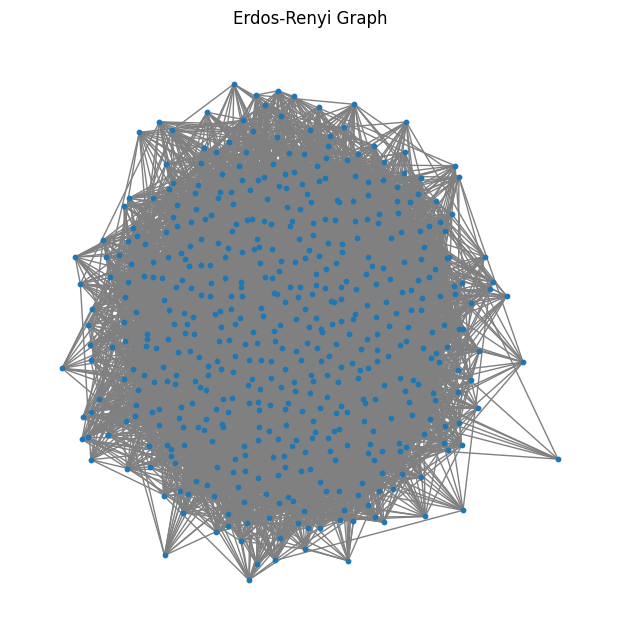

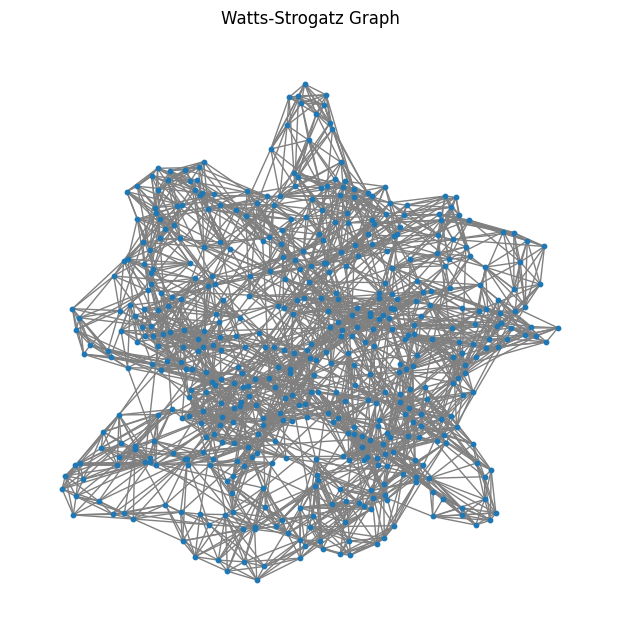

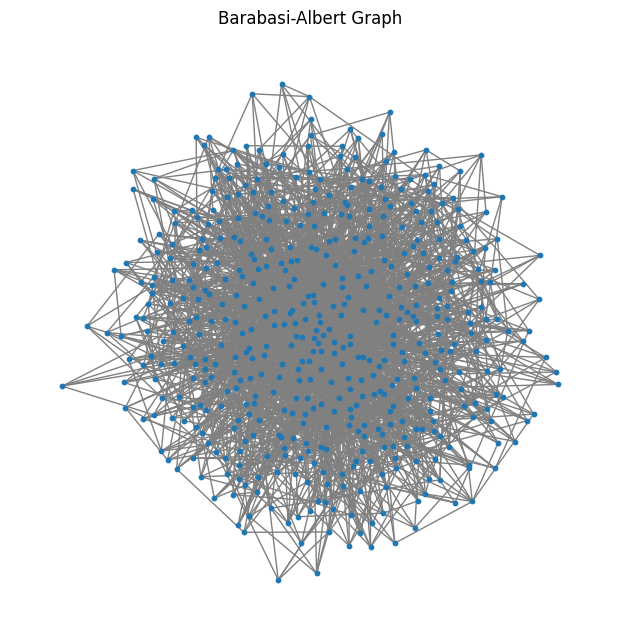

In [5]:
def draw_graph(G, title):
    plt.figure(figsize=(6,6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, node_size=10, edge_color='gray')
    plt.title(title)
    plt.show()

draw_graph(G_er, "Erdos-Renyi Graph")
draw_graph(G_ws, "Watts-Strogatz Graph")
draw_graph(G_ba, "Barabasi-Albert Graph")

In [6]:
nx.write_gexf(G_er, "er_graph.gexf")
nx.write_gexf(G_ws, "ws_graph.gexf")
nx.write_gexf(G_ba, "ba_graph.gexf")

In [7]:
# compute metrics
def compute_metrics(G):
    avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
    clustering = nx.average_clustering(G)
    path_length = nx.average_shortest_path_length(G)
    diameter = nx.diameter(G)

    return avg_degree, clustering, path_length, diameter

metrics_er = compute_metrics(G_er)
metrics_ws = compute_metrics(G_ws)
metrics_ba = compute_metrics(G_ba)

In [8]:
#table
import pandas as pd

data = {
    "Metric": ["Average Degree", "Clustering", "Avg Path Length", "Diameter"],
    "Erdos-Renyi": metrics_er,
    "Watts-Strogatz": metrics_ws,
    "Barabasi-Albert": metrics_ba
}

df = pd.DataFrame(data)
print(df)

            Metric  Erdos-Renyi  Watts-Strogatz  Barabasi-Albert
0   Average Degree    25.612000       10.000000         9.900000
1       Clustering     0.050561        0.488653         0.061039
2  Avg Path Length     2.202509        3.939535         2.789868
3         Diameter     3.000000        7.000000         4.000000


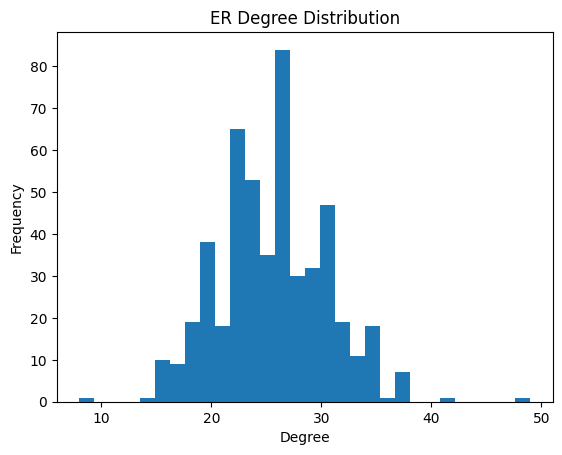

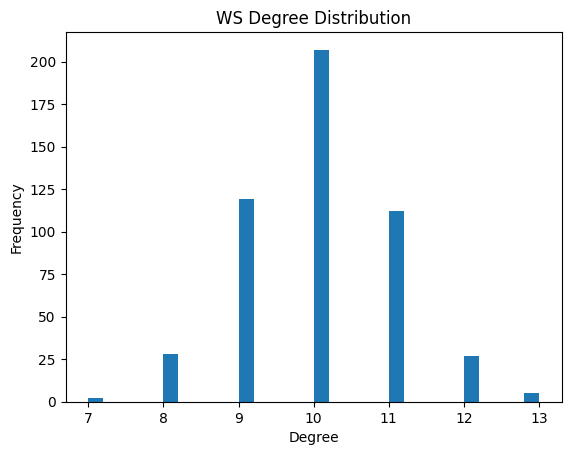

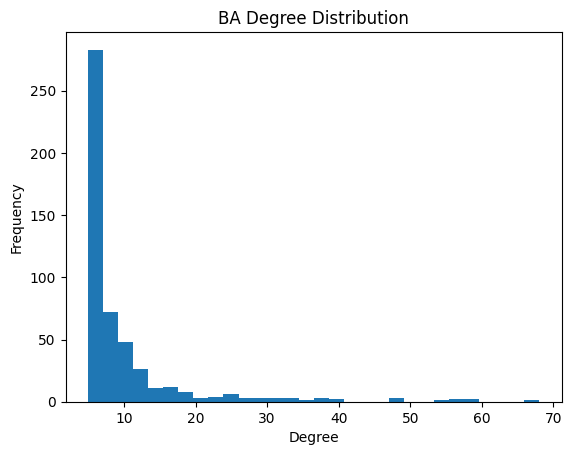

In [9]:
# degree distribution
def plot_degree_dist(G, title):
    degrees = [d for n, d in G.degree()]

    plt.figure()
    plt.hist(degrees, bins=30)
    plt.title(title)
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.show()

plot_degree_dist(G_er, "ER Degree Distribution")
plot_degree_dist(G_ws, "WS Degree Distribution")
plot_degree_dist(G_ba, "BA Degree Distribution")

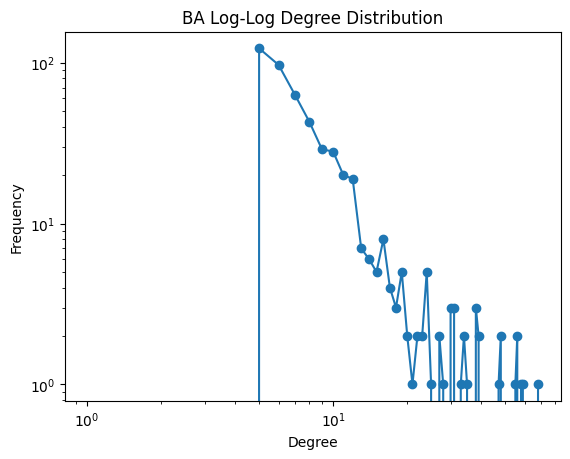

In [10]:
# log log plot for BA graph
import numpy as np

def plot_loglog(G, title):
    degrees = [d for n, d in G.degree()]
    hist = np.bincount(degrees)

    plt.figure()
    plt.loglog(hist, marker='o')
    plt.title(title)
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.show()

plot_loglog(G_ba, "BA Log-Log Degree Distribution")

The Barabasi-Albert model is considered more realistic because it follows the principle of preferential attachment, where new nodes are more likely to connect to already well-connected nodes. This leads to the formation of hubs, which are commonly observed in real-world networks such as social networks and the internet.

In contrast, the Erdos-Renyi model creates edges randomly, resulting in a uniform structure without hubs. The Watts-Strogatz model introduces clustering and short paths but still lacks the scale-free property seen in real networks. Therefore, the Barabasi-Albert model best captures real-world network characteristics.